In [1]:
# Standard library imports
import os
import random
import sys

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cProfile
import pstats

# Configure matplotlib
plt.style.use('fig.style')
figsize = (8,4)

# Add project root to path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
from src import get_alphabet
L = 3
alphabet = [str(i) for i in range(10)]
alpha = len(alphabet)
bg_df = pd.DataFrame(index=range(L), columns=alphabet, data=1.0/alpha)

In [3]:
# Get features
from src import get_pairwise_model_features
features = get_pairwise_model_features(L=L, alphabet=alphabet)

# Create random values from normal distribution
values = np.random.normal(size=len(features))

# Create series with features as index and random values
theta_series = pd.Series(data=values, index=features)
theta_series


((), )          1.222940
((0,), 0)      -1.091205
((0,), 1)       1.310718
((0,), 2)      -0.748210
((0,), 3)      -0.879179
                  ...   
((1, 2), 95)   -0.559746
((1, 2), 96)   -0.160664
((1, 2), 97)    1.407049
((1, 2), 98)    1.441525
((1, 2), 99)    1.069964
Length: 331, dtype: float64

In [4]:
from src.get_hg_projection_matrix import get_hg_projection_matrix
P = get_hg_projection_matrix(features=features, L=L, alphabet=alphabet, bg_df=bg_df, out_type='sparse')

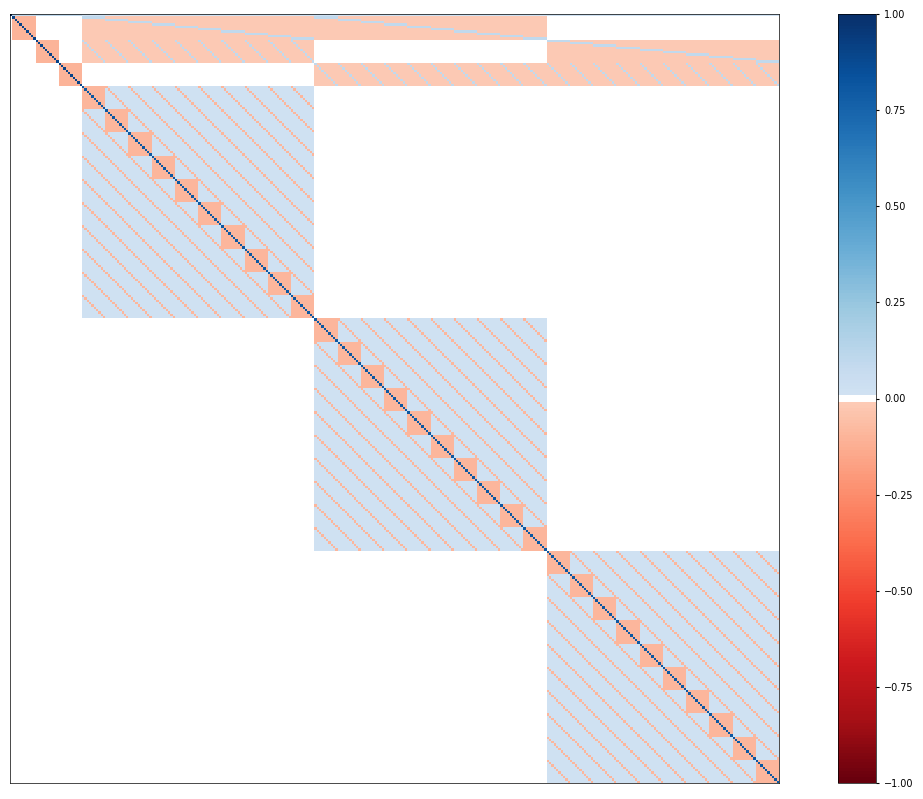

In [5]:
from src.matrix_visualizer import visualize_matrix
visualize_matrix(P.toarray(), show_grid=False)

In [6]:
# Get encoder; use to encode sequences
from src.seq_embedder import SeqEmbedder
embedder = SeqEmbedder(features=features, L=L)
N = len(features)

# Check that gauge matches for every sequence
num_seqs = 100
for _ in range(num_seqs):
    
    # Choose a random sequence
    seq = ''.join(np.random.choice(alphabet, size=L))
    
    # Embed the sequence
    x = embedder.embed(seq)
    
    f = x@theta_series
    f_fixed = x@(P@theta_series)
    
    # Check that the two function values are close      
    assert np.isclose(f, f_fixed), f'{f=}\n{f_fixed=}'
    
print(f'Tested {num_seqs} random sequences; all passed.')

Tested 100 random sequences; all passed.
